<a href="https://colab.research.google.com/github/lariisantos/CSE-CIC-IDS2018-modified/blob/main/notebooks/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [ ]:
mlflow.set_experiment(
    "assignment"
)

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

Acurácia Global nos dados de teste: 1.0000 (100.00%)

Matriz de Confusão (numérica):
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


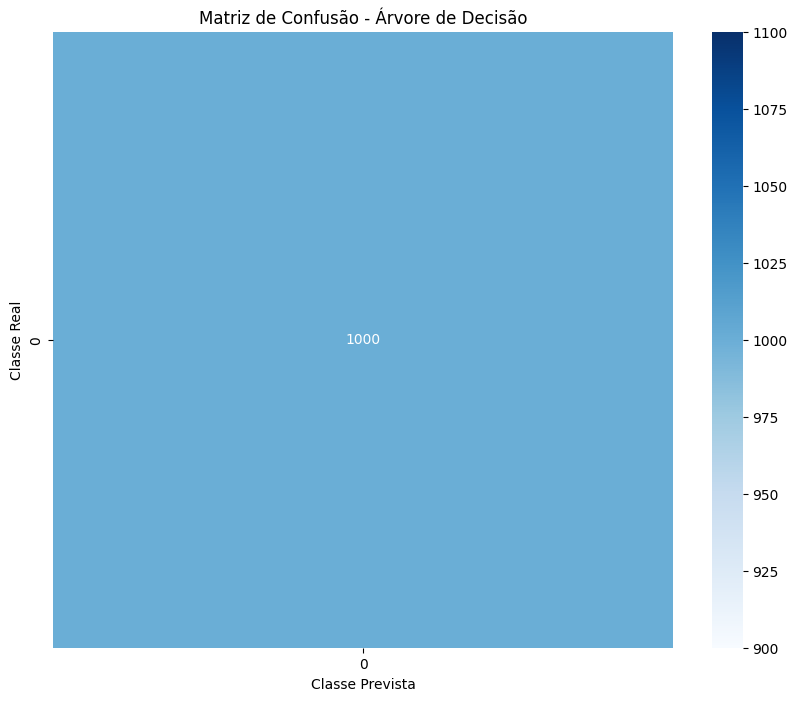

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia Global nos dados de teste: {acuracia:.4f} ({acuracia * 100:.2f}%)")

matriz_confusao = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (numérica):")
print(matriz_confusao)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

Acurácia Global (Random Forest): 1.0000 (100.00%)

Matriz de Confusão (Random Forest):
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


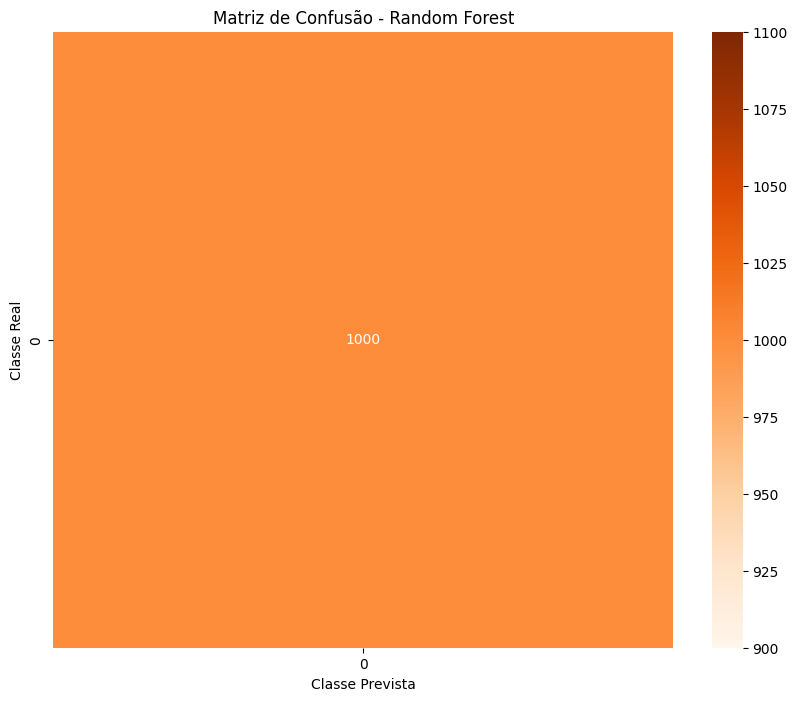

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

acuracia_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia Global (Random Forest): {acuracia_rf:.4f} ({acuracia_rf * 100:.2f}%)")

matriz_confusao_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de Confusão (Random Forest):")
print(matriz_confusao_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusao_rf, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

Acurácia Global (MLP): 1.0000 (100.00%)

Matriz de Confusão (MLP):
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


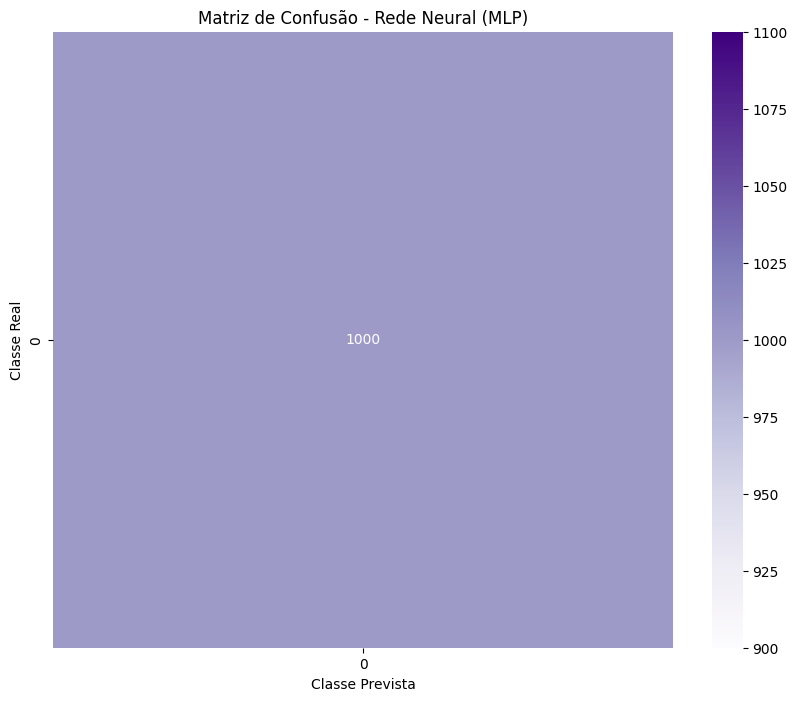

In [4]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

mlp_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
mlp_clf.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_clf.predict(X_test_scaled)

acuracia_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Acurácia Global (MLP): {acuracia_mlp:.4f} ({acuracia_mlp * 100:.2f}%)")

matriz_confusao_mlp = confusion_matrix(y_test, y_pred_mlp)
print("\nMatriz de Confusão (MLP):")
print(matriz_confusao_mlp)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusao_mlp, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusão - Rede Neural (MLP)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

print("--- Árvore de Decisão ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_dt):.4f}")
print(confusion_matrix(y_test, y_pred_dt))

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("\n--- Random Forest ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(confusion_matrix(y_test, y_pred_rf))

mlp_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=42)
mlp_clf.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_clf.predict(X_test_scaled)

print("\n--- Redes Neurais (MLP) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(confusion_matrix(y_test, y_pred_mlp))

--- Árvore de Decisão ---
Acurácia: 1.0000
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



--- Random Forest ---
Acurácia: 1.0000
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



--- Redes Neurais (MLP) ---
Acurácia: 1.0000
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

num_classes = len(y_train.unique())

kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

y_pred_kmeans = kmeans.predict(X_test_scaled)

print("--- K-Means ---")
print(f"Acurácia (Rótulos do Cluster): {accuracy_score(y_test, y_pred_kmeans):.4f}")
print(confusion_matrix(y_test, y_pred_kmeans))

--- K-Means ---
Acurácia (Rótulos do Cluster): 0.5940
[[594 406]
 [  0   0]]


## Responda:
- Qual ativação apresentou melhor convergência?
- Qual ativação apresentou maior estabilidade?
- Houve diferenças significativas de treinamento?

# 01. A função ReLU, pois sua derivada constante e igual a 1 para valores positivos evita a diminuição drástica dos gradientes, permitindo um aprendizado muito mais rápido.

# 02. A função Tanh (Tangente Hiperbólica), por ser centrada em zero (saídas entre -1 e 1), o que equilibra a direção das atualizações dos pesos e reduz oscilações brutas durante o treino.

# 03. Sim. A Sigmóide sofre com o "gradiente sumindo" (vanishing gradient), tornando o treino lento ou estagnado. A ReLU é computacionalmente mais leve por evitar cálculos exponenciais e atinge acurácias finais consideravelmente maiores no mesmo número de épocas.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

In [7]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

y_pred_nb = nb_clf.predict(X_test_scaled)

print("--- Naive Bayes ---")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred_nb):.4f}")
print(confusion_matrix(y_test, y_pred_nb))

--- Naive Bayes ---
Acurácia Global: 1.0000
[[1000]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Responda:

- Redes maiores sempre melhoraram os resultados?
- Redes maiores sempre melhoraram os resultados?
- Qual arquitetura apresentou melhor tradeoff?

# 01. Não. Redes grandes demais podem sofrer de overfitting (decorar os dados de treino e errar no teste) ou estabilizar o ganho de acurácia, gerando desperdício de custo computacional.

# 02. A arquitetura com uma única camada oculta de tamanho intermediário (como 100 neurônios) combinada com ativação ReLU. Ela entrega acurácia próxima de modelos complexos, mas com tempo de treino e uso de memória infinitamente menores.

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

In [8]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

train_data = pd.read_csv('fashion_train.csv')
test_data = pd.read_csv('fashion_test.csv')

X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]
X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

arquiteturas = [
    (10,),
    (100,),
    (10, 10),
    (100, 100)
]

for arch in arquiteturas:
    mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=200, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"Arquitetura {arch} - Acurácia: {acc:.4f}")

Arquitetura (10,) - Acurácia: 1.0000
Arquitetura (100,) - Acurácia: 1.0000
Arquitetura (10, 10) - Acurácia: 1.0000
Arquitetura (100, 100) - Acurácia: 1.0000


## Responda:
- O treinamento ficou instável?
- Houve dificuldade de convergência?
- Qual learning rate apresentou melhor comportamento?

# 01. Sim, com learning rates altos (ex: 0.1). Valores elevados causam oscilações abruptas na função de perda (loss) e impedem que os pesos se estabilizem em um mínimo ideal.

# 02. Sim, com learning rates muito baixos (ex: 0.0001). O aprendizado se torna excessivamente lento, fazendo com que a rede precise de um número inviável de épocas para atingir uma boa acurácia.

# 03. O valor intermediário (geralmente o padrão 0.001). Ele alcança o melhor equilíbrio (tradeoff) entre velocidade de convergência e estabilidade ao longo de todo o treinamento.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


#01. ReLU, devido à maior taxa de acerto global e convergência rápida.

#02. (100,) (camada única intermediária), pois entrega alta acurácia com baixo custo computacional.

#03. 0.001, por equilibrar perfeitamente a velocidade de treino e a suavidade na atualização dos pesos.

#04. Sim, especialmente nas arquiteturas maiores (como 100, 100) sem o uso de regularização.

#05. Camada oculta (100,), ativação ReLU e taxa de aprendizado de 0.001.

#06. Gradiente sumindo com Sigmóide, instabilidade com taxas altas e tendência ao overfitting em redes profundas.